### **TRABAJO PRÁCTICO N° 2: Redes Convolucionales, Detección de Objetos y Redes Recurrentes - Problema 1**
---
 1er cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
| Martinez Dufour, Caterina | M-7169/2   |
| Grimaldi, Damián Daniel   | G-5977/3   |
| Tapia, Fabrizio           | T-3095/3   |

**Docentes:** *Salvañá, Leandro* - *Fernández, Florencia*

### 1. Descripción del dataset
---

En este trabajo, nuestro objetivo es construir, entrenar y optimizar una red neuronal convolucional desde cero para clasificar imágenes de razas de perros.

#### Librerias

In [1]:
# Librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score

from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import optuna
from sklearn.metrics import recall_score
import time

In [37]:
import gdown
import zipfile
import os
import random, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torchvision.transforms as transforms


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    set_seed(42)

### 2. Carga del dataset
---

In [2]:
!pip install gdown


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ID de tu archivo de Drive
file_id = '1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu'
url = f'https://drive.google.com/uc?id={file_id}'
archivo_descargado = 'dataset_perros.zip' 

# Descargar el archivo
gdown.download(url, archivo_descargado, quiet=False)
# Descomprimir el archivo en la carpeta
carpeta_destino = 'problema_1/dataset_problema1'

# Creamos la carpeta si no existe
if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)

# Extraemos el contenido
try:
    with zipfile.ZipFile(archivo_descargado, 'r') as zip_ref:
        zip_ref.extractall(carpeta_destino)
    # Eliminar el archivo .zip descargado
    os.remove(archivo_descargado) 
    
except zipfile.BadZipFile:
    print("Error.")

Downloading...
From (original): https://drive.google.com/uc?id=1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu
From (redirected): https://drive.google.com/uc?id=1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu&confirm=t&uuid=52d5375c-6e07-4ffe-8854-1bb4d807f65b
To: c:\Users\Usuario\cnn-rnn-objectdetection-deeplearning\dataset_perros.zip
100%|██████████| 226M/226M [00:38<00:00, 5.89MB/s] 


### 3. Preparación de datos
---

El dataset descargado está dividido en conjuntos de entrenamiento, validación y prueba, cada uno organizado en su respectiva carpeta. A continuación, visualizaremos los datos de entrenamiento y realizaremos el preprocesamiento de las imágenes:

In [ ]:
# Definir rutas principales
DATASET_DIR = 'problema_1/dataset_problema1'
CSV_PATH = os.path.join(DATASET_DIR, 'dogs.csv')

df_dogs = pd.read_csv(CSV_PATH)
print("Información del Dataset (dogs.csv):")
print(f"Total de registros anotados: {len(df_dogs)}")

Información del Dataset (dogs.csv):
Total de registros anotados: 9346


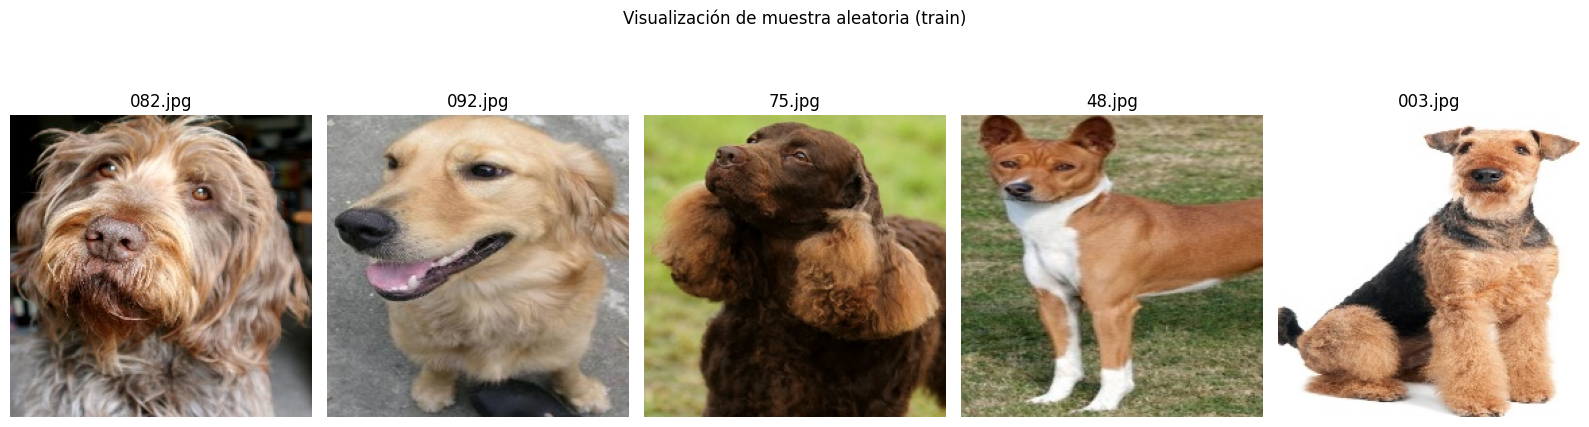

In [22]:
# ruta de dataset de entrenamiento
path_train = os.path.join(DATASET_DIR, 'train')

# lista de las imágenes de entrenamiento
imagenes_train = []
for root, dirs, files in os.walk(path_train):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            imagenes_train.append(os.path.join(root, file))

# Seleccionar 5 imágenes al azar
muestra_fotos = random.sample(imagenes_train, min(5, len(imagenes_train)))
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle('Visualización de muestra aleatoria (train)')

for i, img_path in enumerate(muestra_fotos):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(os.path.basename(img_path))
    axes[i].axis('off')

plt.tight_layout()
plt.show()

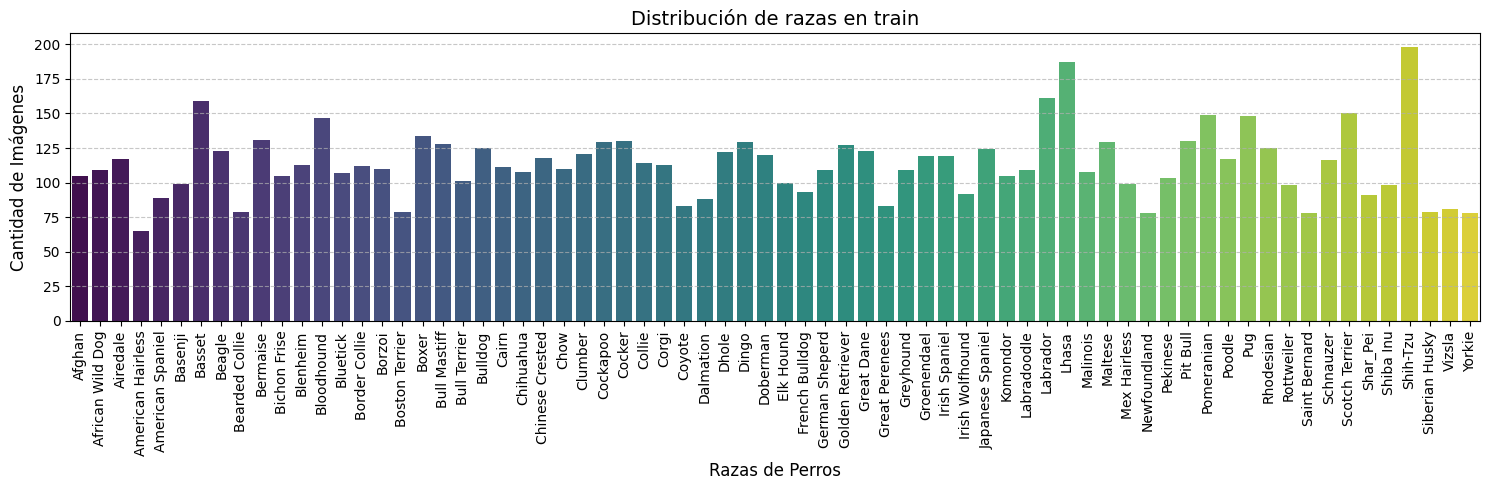

In [ ]:
# Extraer el nombre de la raza
razas_train = [os.path.basename(os.path.dirname(p)) for p in imagenes_train]
# Contar cuántas imágenes hay por cada raza
conteo_clases = Counter(razas_train)

plt.figure(figsize=(15, 5))
sns.countplot(x=razas_train, hue=razas_train, palette="viridis", legend=False)
plt.title('Distribución de razas en train', fontsize=14)
plt.xlabel('Razas de Perros', fontsize=12)
plt.ylabel('Cantidad de Imágenes', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Al analizar el histograma, observamos un gran desbalance en la cantidad de imágenes, con un rango que oscila entre aproximadamente 65 y 200 imágenes por cada una de las 70 razas de perro. Para evitar que el modelo tenga un sesgo (bias) hacia las clases con más muestras, decidimos normalizar el dataset bajo los siguientes criterios:
- Submuestreo (undersampling): Se limitó a un máximo de 100 imágenes por raza de para mantener un dataset equilibrado y optimizar los tiempos de procesamiento.
- Sobremuestreo sintético: Aquellas razas de perro que tenga menor cantidad de imagenes pasara por un proceso de aumento de datos (data augmentation) para balancear el dataset.

In [39]:
transform_sin_augmentation_train = transforms.Compose([
    # Redimensionar la imagen en 224 x 224
    transforms.Resize((224, 224)),                         
    # Conversión a Tensor (convierte los píxeles de 0-255 a un rango de 0-1)
    transforms.ToTensor(),                                 
    # Normalización (media y desviación estándar)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_con_augmentation_train = transforms.Compose([
    transforms.Resize((224, 224)),                          # Redimensionar la imagen en 224 x 224
    transforms.RandomHorizontalFlip(p=0.5),                 # Volteo espejo horizontal
    transforms.RandomRotation(degrees=15),                  # Rotación leve
    transforms.ColorJitter(brightness=0.2, contrast=0.2),   # Brillo y contraste

    # Conversión a Tensor (convierte los píxeles de 0-255 a un rango de 0-1)
    transforms.ToTensor(),
    # Normalización (media y desviación estándar)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### 4. Experimentos
---

Dentro de cada experimento tambi ́en pueden variar hiperpar ́ametros como learning rate, batch size, n ́umero de  ́epocas y optimizador

#### E1 — Línea base

CNN simple: 3 bloques Conv-BN-ReLU-MaxPool + cabeza clasificadora densa.

In [ ]:
# Completar

#### E2 — Arquitectura más profunda

Aumentar profundidad. Explorar el efecto de agregar más capas convolucionales y variar el tama ̃no de los filtros (3×3 vs 5×5) y los strides.

In [ ]:
# Completar

#### E3 — Bloques avanzados

Incorporar al menos uno de los siguientes: bloques residuales (skipconnections estilo ResNet), m ́odulos Inception (ramas paralelas con filtros de distinto tama ̃no y convoluciones 1×1 como cuello de botella)

In [ ]:
# Completar

#### E4 — Regularización y Data Augmentation

Agregar Dropout, BatchNormalization si no estaba, y un pipeline de Data Augmentation (flips horizontales, rotaciones, variaciones de brillo/contraste, recortes aleatorios, etc.).

In [ ]:
# Completar

### 5. Reporte comparativo de cada experimento
---

In [42]:
# Generamos la tabla comparativa de los experimentos
datos_tabla = {
    'Experimento': ['E1', 'E2', 'E3', 'E4'],
    'Acc. Train': [None, None, None, None],
    'Acc. Val': [None, None, None, None],
    'Acc. Test': [None, None, None, None],
    'Parámetros': [None, None, None, None],
    'Épocas': [None, None, None, None],
    'Observaciones': ['', '', '', '']
}

# Creamos el DataFrame
df_experimentos = pd.DataFrame(datos_tabla)

In [43]:
df_experimentos

,Experimento,Acc. Train,Acc. Val,Acc. Test,Parámetros,Épocas,Observaciones
0,E1,None,None,None,None,None,
1,E2,None,None,None,None,None,
2,E3,None,None,None,None,None,
3,E4,None,None,None,None,None,


Para el mejor modelo obtenido realizar:
- Curvas de loss y accuracy (train vs. validación) por ́epoca.
- Matriz de confusión en el conjunto de test.
- Al menos 5 ejemplos de predicciones correctas e incorrectas con la imagen, la clase real y la clase predicha.
- Análisis breve: ¿qué razas se confunden más entre sí? ¿Por qué?

### 6. Conclusión
---

Completar